# 11 — Evaluasi Akhir Model Klasifikasi Jenis Awan

Notebook ini menyusun evaluasi akhir model berdasarkan artefak yang telah
dihasilkan oleh:

- `09_validasi_model.ipynb`;
- `10_pengujian_model.ipynb`.

Notebook ini tidak menjalankan inference ulang. Prediksi validation dan test
dibaca langsung dari file CSV yang telah disimpan sehingga data test tidak
digunakan lebih dari satu kali untuk menjalankan model.

Tujuan evaluasi:

1. Memeriksa konsistensi model, kelas, dan checkpoint.
2. Membandingkan metrik validation dan test.
3. Mengukur generalization gap.
4. Menghitung interval kepercayaan metrik test.
5. Membandingkan performa setiap kelas.
6. Mengidentifikasi kelas dengan performa terendah.
7. Menganalisis pasangan kelas yang sering tertukar.
8. Mengevaluasi kalibrasi confidence pada test split.
9. Menyusun ringkasan evaluasi yang dapat digunakan dalam laporan penelitian.
10. Menyimpan seluruh hasil evaluasi secara terstruktur.

Notebook ini hanya membaca artefak hasil tahap sebelumnya dan tidak
memperbarui bobot model.

In [1]:
from pathlib import Path
from datetime import datetime

import hashlib
import json
import re
import sys

try:
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import seaborn as sns

    from IPython.display import display
    from sklearn.metrics import (
        accuracy_score,
        balanced_accuracy_score,
        f1_score,
    )

except ImportError as exc:
    raise ImportError(
        "Dependency evaluasi belum lengkap.\n\n"
        "Aktifkan .venv, kemudian jalankan melalui terminal VS Code:\n\n"
        r".\.venv\Scripts\python.exe -m pip install -r requirements.txt"
    ) from exc


pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)
pd.set_option("display.precision", 6)

sns.set_theme(
    style="whitegrid",
    context="notebook",
)


print(f"Python       : {sys.version.split()[0]}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print("Mode         : Evaluasi dari artefak tersimpan")
print("Inference    : Tidak dijalankan")

Python       : 3.11.9
NumPy        : 2.4.6
Pandas       : 3.0.5
Mode         : Evaluasi dari artefak tersimpan
Inference    : Tidak dijalankan


In [3]:
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR


DATASET_DIR = PROJECT_DIR / "dataset"
PROCESSED_DIR = DATASET_DIR / "processed"

MODELS_DIR = PROJECT_DIR / "models"
LOGS_DIR = PROJECT_DIR / "logs"

MODEL_CONFIG_PATH = (
    PROCESSED_DIR
    / "model_config.json"
)


path_table = pd.DataFrame({
    "Nama": [
        "PROJECT_DIR",
        "PROCESSED_DIR",
        "MODELS_DIR",
        "LOGS_DIR",
        "MODEL_CONFIG_PATH",
    ],
    "Path": [
        PROJECT_DIR,
        PROCESSED_DIR,
        MODELS_DIR,
        LOGS_DIR,
        MODEL_CONFIG_PATH,
    ],
})

path_table["Ada"] = (
    path_table["Path"]
    .map(Path.exists)
)


display(path_table)

,Nama,Path,Ada
0,PROJECT_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification,True
1,PROCESSED_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\processed,True
2,MODELS_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\models,True
3,LOGS_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\logs,True
4,MODEL_CONFIG_PATH,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\processed\model_config.json,True


In [5]:
required_directories = [
    PROJECT_DIR,
    PROCESSED_DIR,
    MODELS_DIR,
    LOGS_DIR,
]

missing_directories = [
    path
    for path in required_directories
    if not path.is_dir()
]


if missing_directories:
    formatted_paths = "\n".join(
        f"- {path}"
        for path in missing_directories
    )

    raise FileNotFoundError(
        "Folder prasyarat belum tersedia:\n"
        f"{formatted_paths}"
    )


if not MODEL_CONFIG_PATH.is_file():
    raise FileNotFoundError(
        "Konfigurasi model tidak ditemukan:\n"
        f"{MODEL_CONFIG_PATH}\n\n"
        "Pastikan 07_persiapan_model.ipynb telah selesai dijalankan."
    )


print("Prasyarat awal evaluasi tersedia.")

Prasyarat awal evaluasi tersedia.


In [7]:
with MODEL_CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    model_config = json.load(file)


required_model_keys = {
    "model_name",
    "num_classes",
    "class_to_idx",
    "input_shape",
}


missing_model_keys = (
    required_model_keys
    - set(model_config.keys())
)


if missing_model_keys:
    raise KeyError(
        "model_config.json belum lengkap. "
        f"Kunci yang hilang: {sorted(missing_model_keys)}"
    )


MODEL_NAME = str(
    model_config["model_name"]
)

NUM_CLASSES = int(
    model_config["num_classes"]
)

CLASS_TO_IDX = {
    str(class_name): int(class_id)
    for class_name, class_id
    in model_config["class_to_idx"].items()
}

IDX_TO_CLASS = {
    class_id: class_name
    for class_name, class_id
    in CLASS_TO_IDX.items()
}

LABEL_IDS = np.arange(
    NUM_CLASSES,
    dtype=np.int64,
)

CLASS_NAMES = [
    IDX_TO_CLASS[class_id]
    for class_id in LABEL_IDS
]

SEED = int(
    model_config.get(
        "seed",
        42,
    )
)

SAFE_MODEL_NAME = re.sub(
    r"[^A-Za-z0-9_.-]+",
    "_",
    MODEL_NAME,
)


configuration_table = pd.DataFrame({
    "Parameter": [
        "Nama model",
        "Jumlah kelas",
        "Input shape",
        "Seed evaluasi",
        "Urutan kelas",
    ],
    "Nilai": [
        MODEL_NAME,
        NUM_CLASSES,
        model_config["input_shape"],
        SEED,
        CLASS_NAMES,
    ],
})


display(configuration_table)

,Parameter,Nilai
0,Nama model,resnet18
1,Jumlah kelas,7
2,Input shape,"[3, 224, 224]"
3,Seed evaluasi,42
4,Urutan kelas,"[1_cumulus, 2_altocumulus, 3_cirrus, 4_clearsky, 5_stratocumulus, 6_cumulonimbus, 7_mixed]"


Secara default, notebook memilih folder validasi dan pengujian lengkap yang
terakhir dibuat.

Untuk reproduksi laporan tertentu, isi `SELECTED_VALIDATION_RUN` dan
`SELECTED_TEST_RUN` dengan path folder yang ingin digunakan. Path dapat
ditulis relatif terhadap folder project.

In [8]:
# Biarkan None untuk memilih run terbaru secara otomatis.
#
# Contoh:
# SELECTED_VALIDATION_RUN = (
#     "logs/resnet18_validation_20260826_090000"
# )
#
# SELECTED_TEST_RUN = (
#     "logs/resnet18_final_test_20260826_100000"
# )

SELECTED_VALIDATION_RUN = None
SELECTED_TEST_RUN = None

In [9]:
def select_complete_run(
    parent_directory: Path,
    pattern: str,
    required_files: list[str],
    selected_run=None,
) -> Path:
    """
    Memilih folder run yang berisi seluruh artefak wajib.
    """
    if selected_run is not None:
        selected_path = Path(selected_run)

        if not selected_path.is_absolute():
            selected_path = (
                PROJECT_DIR
                / selected_path
            )

        selected_path = selected_path.resolve()

        if not selected_path.is_dir():
            raise FileNotFoundError(
                "Folder run yang dipilih tidak ditemukan:\n"
                f"{selected_path}"
            )

        missing_files = [
            file_name
            for file_name in required_files
            if not (
                selected_path
                / file_name
            ).is_file()
        ]

        if missing_files:
            raise FileNotFoundError(
                "Folder run belum lengkap. "
                f"File yang hilang: {missing_files}"
            )

        return selected_path


    candidate_directories = sorted(
        [
            path
            for path in parent_directory.glob(pattern)
            if path.is_dir()
        ],
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )


    for candidate_directory in candidate_directories:
        is_complete = all(
            (
                candidate_directory
                / file_name
            ).is_file()
            for file_name in required_files
        )

        if is_complete:
            return candidate_directory


    raise FileNotFoundError(
        "Tidak ditemukan folder run lengkap untuk pola:\n"
        f"{pattern}"
    )

In [10]:
VALIDATION_REQUIRED_FILES = [
    "validation_summary.json",
    "validation_predictions.csv",
    "validation_per_class.csv",
]

TEST_REQUIRED_FILES = [
    "test_metrics.json",
    "test_predictions.csv",
    "test_per_class_metrics.csv",
    "test_error_pairs.csv",
]


VALIDATION_RUN_DIR = select_complete_run(
    parent_directory=LOGS_DIR,
    pattern=f"{SAFE_MODEL_NAME}_validation_*",
    required_files=VALIDATION_REQUIRED_FILES,
    selected_run=SELECTED_VALIDATION_RUN,
)

TEST_RUN_DIR = select_complete_run(
    parent_directory=LOGS_DIR,
    pattern=f"{SAFE_MODEL_NAME}_final_test_*",
    required_files=TEST_REQUIRED_FILES,
    selected_run=SELECTED_TEST_RUN,
)


selected_run_table = pd.DataFrame({
    "Tahap": [
        "Validation",
        "Final test",
    ],
    "Folder": [
        str(
            VALIDATION_RUN_DIR.relative_to(
                PROJECT_DIR
            )
        ),
        str(
            TEST_RUN_DIR.relative_to(
                PROJECT_DIR
            )
        ),
    ],
})


display(selected_run_table)

,Tahap,Folder
0,Validation,logs\resnet18_validation_20260826_104918
1,Final test,logs\resnet18_final_test_20260826_112917


In [11]:
VALIDATION_SUMMARY_PATH = (
    VALIDATION_RUN_DIR
    / "validation_summary.json"
)

VALIDATION_PREDICTIONS_PATH = (
    VALIDATION_RUN_DIR
    / "validation_predictions.csv"
)

VALIDATION_PER_CLASS_PATH = (
    VALIDATION_RUN_DIR
    / "validation_per_class.csv"
)


TEST_SUMMARY_PATH = (
    TEST_RUN_DIR
    / "test_metrics.json"
)

TEST_PREDICTIONS_PATH = (
    TEST_RUN_DIR
    / "test_predictions.csv"
)

TEST_PER_CLASS_PATH = (
    TEST_RUN_DIR
    / "test_per_class_metrics.csv"
)

TEST_ERROR_PAIRS_PATH = (
    TEST_RUN_DIR
    / "test_error_pairs.csv"
)


input_artifact_table = pd.DataFrame({
    "Artefak": [
        "Ringkasan validation",
        "Prediksi validation",
        "Metrik kelas validation",
        "Ringkasan test",
        "Prediksi test",
        "Metrik kelas test",
        "Pasangan kesalahan test",
    ],
    "Path": [
        VALIDATION_SUMMARY_PATH,
        VALIDATION_PREDICTIONS_PATH,
        VALIDATION_PER_CLASS_PATH,
        TEST_SUMMARY_PATH,
        TEST_PREDICTIONS_PATH,
        TEST_PER_CLASS_PATH,
        TEST_ERROR_PAIRS_PATH,
    ],
})


input_artifact_table["Ada"] = (
    input_artifact_table["Path"]
    .map(Path.is_file)
)

input_artifact_table["Ukuran byte"] = (
    input_artifact_table["Path"]
    .map(
        lambda path: (
            path.stat().st_size
            if path.is_file()
            else None
        )
    )
)


display(input_artifact_table)

,Artefak,Path,Ada,Ukuran byte
0,Ringkasan validation,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\logs\resnet18_validation_20260826_104918\validation_summary.json,True,2646
1,Prediksi validation,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\logs\resnet18_validation_20260826_104918\validation_predictions.csv,True,263650
2,Metrik kelas validation,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\logs\resnet18_validation_20260826_104918\validation_per_class.csv,True,979
3,Ringkasan test,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\logs\resnet18_final_test_20260826_112917\test_metrics.json,True,3521
4,Prediksi test,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\logs\resnet18_final_test_20260826_112917\test_predictions.csv,True,2253990
5,Metrik kelas test,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\logs\resnet18_final_test_20260826_112917\test_per_class_metrics.csv,True,807
6,Pasangan kesalahan test,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\logs\resnet18_final_test_20260826_112917\test_error_pairs.csv,True,2244


In [12]:
def read_json(
    path: Path,
) -> dict:
    """
    Membaca file JSON dan memastikan hasilnya berupa dictionary.
    """
    with path.open(
        "r",
        encoding="utf-8",
    ) as file:
        data = json.load(file)

    if not isinstance(data, dict):
        raise TypeError(
            f"Isi JSON harus berupa dictionary: {path}"
        )

    return data


def normalize_boolean_series(
    series: pd.Series,
) -> pd.Series:
    """
    Mengubah kolom boolean CSV menjadi dtype bool secara konsisten.
    """
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)

    mapping = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
    }

    normalized = (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map(mapping)
    )

    if normalized.isna().any():
        invalid_values = (
            series.loc[normalized.isna()]
            .astype(str)
            .unique()
            .tolist()
        )

        raise ValueError(
            "Nilai kolom boolean tidak dikenali: "
            f"{invalid_values}"
        )

    return normalized.astype(bool)

In [13]:
validation_summary = read_json(
    VALIDATION_SUMMARY_PATH
)

test_summary = read_json(
    TEST_SUMMARY_PATH
)


validation_predictions_df = pd.read_csv(
    VALIDATION_PREDICTIONS_PATH
)

test_predictions_df = pd.read_csv(
    TEST_PREDICTIONS_PATH
)

validation_per_class_df = pd.read_csv(
    VALIDATION_PER_CLASS_PATH
)

test_per_class_df = pd.read_csv(
    TEST_PER_CLASS_PATH
)

test_error_pairs_df = pd.read_csv(
    TEST_ERROR_PAIRS_PATH
)


validation_predictions_df["correct"] = (
    normalize_boolean_series(
        validation_predictions_df["correct"]
    )
)

test_predictions_df["correct"] = (
    normalize_boolean_series(
        test_predictions_df["correct"]
    )
)


print(
    "Jumlah prediksi validation : "
    f"{len(validation_predictions_df):,}"
)

print(
    "Jumlah prediksi test       : "
    f"{len(test_predictions_df):,}"
)

print(
    "Jumlah kelas validation    : "
    f"{len(validation_per_class_df):,}"
)

print(
    "Jumlah kelas test          : "
    f"{len(test_per_class_df):,}"
)

Jumlah prediksi validation : 1,969
Jumlah prediksi test       : 9,000
Jumlah kelas validation    : 7
Jumlah kelas test          : 7


In [14]:
def calculate_sha256(
    path: Path,
    chunk_size: int = 1024 * 1024,
) -> str:
    """
    Menghitung SHA-256 tanpa memuat seluruh file ke memori.
    """
    digest = hashlib.sha256()

    with path.open("rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()

In [15]:
checkpoint_relative_path = Path(
    test_summary["checkpoint"]["path"]
)

if checkpoint_relative_path.is_absolute():
    CHECKPOINT_PATH = checkpoint_relative_path
else:
    CHECKPOINT_PATH = (
        PROJECT_DIR
        / checkpoint_relative_path
    )


if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        "Checkpoint yang tercatat pada test_metrics.json "
        "tidak ditemukan:\n"
        f"{CHECKPOINT_PATH}"
    )


CHECKPOINT_SHA256_ACTUAL = calculate_sha256(
    CHECKPOINT_PATH
)


SOURCE_ARTIFACTS = {
    "model_config": MODEL_CONFIG_PATH,
    "validation_summary": VALIDATION_SUMMARY_PATH,
    "validation_predictions": VALIDATION_PREDICTIONS_PATH,
    "validation_per_class": VALIDATION_PER_CLASS_PATH,
    "test_summary": TEST_SUMMARY_PATH,
    "test_predictions": TEST_PREDICTIONS_PATH,
    "test_per_class": TEST_PER_CLASS_PATH,
    "test_error_pairs": TEST_ERROR_PAIRS_PATH,
    "checkpoint": CHECKPOINT_PATH,
}


SOURCE_HASHES_BEFORE = {
    artifact_name: calculate_sha256(path)
    for artifact_name, path
    in SOURCE_ARTIFACTS.items()
}


hash_table = pd.DataFrame({
    "Artefak": SOURCE_HASHES_BEFORE.keys(),
    "SHA-256": SOURCE_HASHES_BEFORE.values(),
})


display(hash_table)

,Artefak,SHA-256
0,model_config,d9ee02e3a15742953868fb2f660bb08c442b56bc27455eade730192849893e37
1,validation_summary,f5a9d1d2ee54caad3778f28c88ed3cd163e90acf0e01f978ddbf5ac4aefbf6a7
2,validation_predictions,c1c348021ba7e43bd3de1c269a1724d41558a671ddc869bce4c48d86a1293b5e
3,validation_per_class,a62ee1da94d2c682f3323119719d1ff20be00e235aa360cf1f4bed8eecc60955
4,test_summary,56078c7a7dfb21f3aa6a09bfdc17db2513965ae1c465b6d23afa4e5b138bddc3
5,test_predictions,693d2478634a528a77a46705c0e8aa7c7132e7d0786386ebe3e72d68537f8881
6,test_per_class,495487afafa1cf3a69d62c21437779ba4a1a3e6efe29b85574e837248e726f8d
7,test_error_pairs,9e1a1ee055abf366912f1a0e6e016c7ed22a53d0a06348cb16c0e532f1a9bcb1
8,checkpoint,e9f134760047e2075fe154a0e99c32786e456e6e37790ea1e46e1717af6eb0aa


In [16]:
required_validation_prediction_columns = {
    "image_path",
    "true_class_id",
    "true_class",
    "predicted_class_id",
    "predicted_class",
    "correct",
    "confidence",
}

required_test_prediction_columns = {
    "sample_id",
    "image_path",
    "true_id",
    "true_class",
    "predicted_id",
    "predicted_class",
    "confidence",
    "confidence_margin",
    "correct",
}

required_validation_per_class_columns = {
    "class_id",
    "class_name",
    "support",
    "precision",
    "recall_sensitivity",
    "f1_score",
}

required_test_per_class_columns = {
    "class_id",
    "class_name",
    "support",
    "precision",
    "recall",
    "f1_score",
    "error_rate",
}


schema_checks = {
    "Kolom prediksi validation lengkap": (
        required_validation_prediction_columns
        .issubset(
            validation_predictions_df.columns
        )
    ),

    "Kolom prediksi test lengkap": (
        required_test_prediction_columns
        .issubset(
            test_predictions_df.columns
        )
    ),

    "Kolom kelas validation lengkap": (
        required_validation_per_class_columns
        .issubset(
            validation_per_class_df.columns
        )
    ),

    "Kolom kelas test lengkap": (
        required_test_per_class_columns
        .issubset(
            test_per_class_df.columns
        )
    ),
}


schema_check_df = pd.DataFrame({
    "Pemeriksaan": schema_checks.keys(),
    "Berhasil": schema_checks.values(),
})


display(schema_check_df)


failed_schema_checks = [
    check_name
    for check_name, status
    in schema_checks.items()
    if not status
]


if failed_schema_checks:
    raise KeyError(
        "Kontrak kolom artefak belum terpenuhi:\n- "
        + "\n- ".join(failed_schema_checks)
    )

,Pemeriksaan,Berhasil
0,Kolom prediksi validation lengkap,True
1,Kolom prediksi test lengkap,True
2,Kolom kelas validation lengkap,True
3,Kolom kelas test lengkap,True


In [17]:
validation_model_mapping = {
    str(class_name): int(class_id)
    for class_name, class_id
    in validation_summary[
        "model"
    ][
        "class_to_idx"
    ].items()
}

test_model_mapping = {
    str(class_name): int(class_id)
    for class_name, class_id
    in test_summary[
        "model"
    ][
        "class_to_idx"
    ].items()
}


validation_checkpoint_sha = str(
    validation_summary[
        "checkpoint"
    ][
        "sha256"
    ]
)

test_checkpoint_sha = str(
    test_summary[
        "checkpoint"
    ][
        "sha256"
    ]
)


test_accuracy_from_predictions = (
    test_predictions_df["correct"]
    .mean()
)

validation_accuracy_from_predictions = (
    validation_predictions_df["correct"]
    .mean()
)


provenance_checks = {
    "Model validation sesuai konfigurasi": (
        validation_summary["model"]["model_name"]
        == MODEL_NAME
    ),

    "Model test sesuai konfigurasi": (
        test_summary["model"]["model_name"]
        == MODEL_NAME
    ),

    "Pemetaan kelas validation konsisten": (
        validation_model_mapping
        == CLASS_TO_IDX
    ),

    "Pemetaan kelas test konsisten": (
        test_model_mapping
        == CLASS_TO_IDX
    ),

    "Checkpoint validation dan test sama": (
        validation_checkpoint_sha
        == test_checkpoint_sha
    ),

    "Hash checkpoint aktual sesuai validation": (
        CHECKPOINT_SHA256_ACTUAL
        == validation_checkpoint_sha
    ),

    "Hash checkpoint aktual sesuai test": (
        CHECKPOINT_SHA256_ACTUAL
        == test_checkpoint_sha
    ),

    "Jumlah kelas validation lengkap": (
        len(validation_per_class_df)
        == NUM_CLASSES
    ),

    "Jumlah kelas test lengkap": (
        len(test_per_class_df)
        == NUM_CLASSES
    ),

    "Jumlah prediksi validation sesuai ringkasan": (
        len(validation_predictions_df)
        == int(
            validation_summary[
                "validation_data"
            ][
                "number_of_images"
            ]
        )
    ),

    "Jumlah prediksi test sesuai ringkasan": (
        len(test_predictions_df)
        == int(
            test_summary[
                "data"
            ][
                "number_of_samples"
            ]
        )
    ),

    "Accuracy validation dapat direproduksi": (
        np.isclose(
            validation_accuracy_from_predictions,
            validation_summary[
                "metrics"
            ][
                "accuracy"
            ],
            atol=1e-12,
        )
    ),

    "Accuracy test dapat direproduksi": (
        np.isclose(
            test_accuracy_from_predictions,
            test_summary[
                "metrics"
            ][
                "accuracy"
            ],
            atol=1e-12,
        )
    ),

    "Validation tidak menggunakan data test": (
        validation_summary[
            "data_usage"
        ][
            "test_data_used"
        ]
        is False
    ),

    "Test ditandai sebagai evaluasi akhir": (
        test_summary[
            "evaluation_policy"
        ][
            "final_evaluation"
        ]
        is True
    ),

    "Test tidak digunakan memilih model": (
        test_summary[
            "evaluation_policy"
        ][
            "model_selection_using_test"
        ]
        is False
    ),

    "Test tidak digunakan tuning": (
        test_summary[
            "evaluation_policy"
        ][
            "hyperparameter_tuning_using_test"
        ]
        is False
    ),
}


provenance_check_df = pd.DataFrame({
    "Pemeriksaan": provenance_checks.keys(),
    "Berhasil": provenance_checks.values(),
})


display(provenance_check_df)


failed_provenance_checks = [
    check_name
    for check_name, status
    in provenance_checks.items()
    if not status
]


if failed_provenance_checks:
    raise RuntimeError(
        "Audit konsistensi gagal:\n- "
        + "\n- ".join(
            failed_provenance_checks
        )
    )


print("Model, kelas, checkpoint, dan kebijakan data konsisten.")

,Pemeriksaan,Berhasil
0,Model validation sesuai konfigurasi,True
1,Model test sesuai konfigurasi,True
2,Pemetaan kelas validation konsisten,True
3,Pemetaan kelas test konsisten,True
4,Checkpoint validation dan test sama,True
5,Hash checkpoint aktual sesuai validation,True
6,Hash checkpoint aktual sesuai test,True
7,Jumlah kelas validation lengkap,True
8,Jumlah kelas test lengkap,True
9,Jumlah prediksi validation sesuai ringkasan,True


Model, kelas, checkpoint, dan kebijakan data konsisten.


In [18]:
EVALUATION_RUN_ID = (
    datetime.now()
    .astimezone()
    .strftime("%Y%m%d_%H%M%S_%f")
)

EVALUATION_OUTPUT_DIR = (
    LOGS_DIR
    / f"{SAFE_MODEL_NAME}_evaluation_{EVALUATION_RUN_ID}"
)

EVALUATION_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=False,
)


OVERALL_COMPARISON_PATH = (
    EVALUATION_OUTPUT_DIR
    / "overall_metric_comparison.csv"
)

OVERALL_COMPARISON_FIGURE_PATH = (
    EVALUATION_OUTPUT_DIR
    / "overall_metric_comparison.png"
)

BOOTSTRAP_CI_PATH = (
    EVALUATION_OUTPUT_DIR
    / "test_bootstrap_confidence_intervals.csv"
)

PER_CLASS_COMPARISON_PATH = (
    EVALUATION_OUTPUT_DIR
    / "per_class_generalization.csv"
)

PER_CLASS_FIGURE_PATH = (
    EVALUATION_OUTPUT_DIR
    / "per_class_generalization.png"
)

ERROR_ANALYSIS_PATH = (
    EVALUATION_OUTPUT_DIR
    / "dominant_error_pairs.csv"
)

CONFIDENCE_GROUP_PATH = (
    EVALUATION_OUTPUT_DIR
    / "test_confidence_groups.csv"
)

RELIABILITY_PATH = (
    EVALUATION_OUTPUT_DIR
    / "test_reliability.csv"
)

RELIABILITY_FIGURE_PATH = (
    EVALUATION_OUTPUT_DIR
    / "test_reliability_diagram.png"
)

ACCEPTANCE_PATH = (
    EVALUATION_OUTPUT_DIR
    / "acceptance_criteria.csv"
)

EVALUATION_SUMMARY_PATH = (
    EVALUATION_OUTPUT_DIR
    / "model_evaluation_summary.json"
)

EVALUATION_REPORT_PATH = (
    EVALUATION_OUTPUT_DIR
    / "model_evaluation_report.md"
)


print(
    "Folder evaluasi:\n"
    f"{EVALUATION_OUTPUT_DIR.relative_to(PROJECT_DIR)}"
)

Folder evaluasi:
logs\resnet18_evaluation_20260826_141227_532648


Generalization gap dihitung sebagai:

\[
\text{gap} = \text{metrik test} - \text{metrik validation}
\]

Untuk accuracy, balanced accuracy, precision, recall, dan F1-score, nilai positif
menunjukkan nilai test lebih tinggi. Untuk log loss, nilai yang lebih kecil
lebih baik.

Selisih validation dan test tidak langsung digunakan sebagai bukti overfitting.
Interpretasi tetap mempertimbangkan ukuran sampel, interval kepercayaan, dan
performa setiap kelas.

In [19]:
validation_metrics = (
    validation_summary["metrics"]
)

test_metrics = (
    test_summary["metrics"]
)


metric_specifications = [
    {
        "metric": "Accuracy",
        "validation_key": "accuracy",
        "test_key": "accuracy",
        "direction": "higher_is_better",
    },
    {
        "metric": "Balanced accuracy",
        "validation_key": "balanced_accuracy",
        "test_key": "balanced_accuracy",
        "direction": "higher_is_better",
    },
    {
        "metric": "Precision macro",
        "validation_key": "precision_macro",
        "test_key": "precision_macro",
        "direction": "higher_is_better",
    },
    {
        "metric": "Recall macro",
        "validation_key": "recall_macro",
        "test_key": "recall_macro",
        "direction": "higher_is_better",
    },
    {
        "metric": "F1-score macro",
        "validation_key": "f1_macro",
        "test_key": "f1_macro",
        "direction": "higher_is_better",
    },
    {
        "metric": "F1-score weighted",
        "validation_key": "f1_weighted",
        "test_key": "f1_weighted",
        "direction": "higher_is_better",
    },
    {
        "metric": "Log loss",
        "validation_key": "probability_log_loss",
        "test_key": "log_loss",
        "direction": "lower_is_better",
    },
]


validation_top_k_keys = {
    key
    for key in validation_metrics
    if (
        key.startswith("top_")
        and key.endswith("_accuracy")
    )
}

test_top_k_keys = {
    key
    for key in test_metrics
    if (
        key.startswith("top_")
        and key.endswith("_accuracy")
    )
}


for top_k_key in sorted(
    validation_top_k_keys
    & test_top_k_keys
):
    metric_specifications.append({
        "metric": (
            top_k_key
            .replace("_", " ")
            .title()
        ),
        "validation_key": top_k_key,
        "test_key": top_k_key,
        "direction": "higher_is_better",
    })

In [20]:
comparison_records = []


for specification in metric_specifications:
    validation_value = float(
        validation_metrics[
            specification["validation_key"]
        ]
    )

    test_value = float(
        test_metrics[
            specification["test_key"]
        ]
    )

    difference = (
        test_value
        - validation_value
    )

    relative_difference_percent = (
        difference
        / abs(validation_value)
        * 100.0
        if validation_value != 0
        else np.nan
    )


    if specification["direction"] == "higher_is_better":
        comparison_status = (
            "Test lebih tinggi atau sama"
            if difference >= 0
            else "Test lebih rendah"
        )

    else:
        comparison_status = (
            "Test lebih rendah atau sama"
            if difference <= 0
            else "Test lebih tinggi"
        )


    comparison_records.append({
        "metric": specification["metric"],
        "validation": validation_value,
        "test": test_value,
        "test_minus_validation": difference,
        "relative_change_percent": (
            relative_difference_percent
        ),
        "direction": specification["direction"],
        "comparison": comparison_status,
    })


overall_comparison_df = pd.DataFrame(
    comparison_records
)


display(
    overall_comparison_df.style.format({
        "validation": "{:.6f}",
        "test": "{:.6f}",
        "test_minus_validation": "{:+.6f}",
        "relative_change_percent": "{:+.2f}%",
    })
)

,metric,validation,test,test_minus_validation,relative_change_percent,direction,comparison
0,Accuracy,0.917217,0.763778,-0.153439,-16.73%,higher_is_better,Test lebih rendah
1,Balanced accuracy,0.920316,0.716141,-0.204175,-22.19%,higher_is_better,Test lebih rendah
2,Precision macro,0.918118,0.808050,-0.110068,-11.99%,higher_is_better,Test lebih rendah
3,Recall macro,0.920316,0.716141,-0.204175,-22.19%,higher_is_better,Test lebih rendah
4,F1-score macro,0.918438,0.739866,-0.178572,-19.44%,higher_is_better,Test lebih rendah
5,F1-score weighted,0.916976,0.760221,-0.156755,-17.09%,higher_is_better,Test lebih rendah
6,Log loss,0.413334,0.759603,+0.346269,+83.77%,lower_is_better,Test lebih tinggi
7,Top 3 Accuracy,0.994413,0.950778,-0.043636,-4.39%,higher_is_better,Test lebih rendah


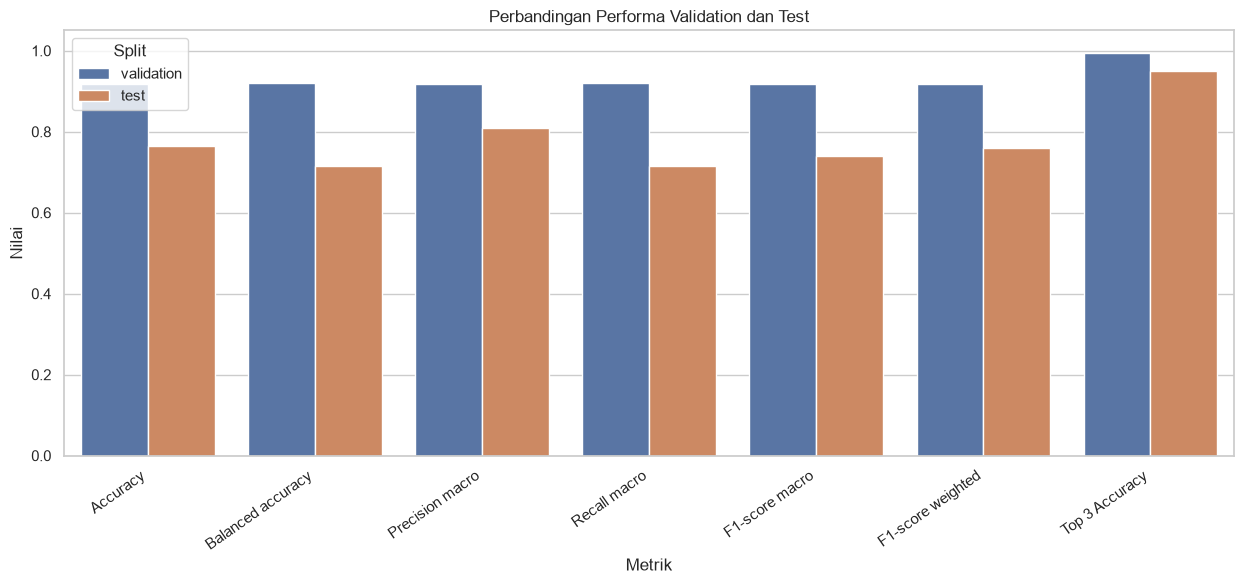

In [21]:
higher_is_better_df = (
    overall_comparison_df
    .loc[
        overall_comparison_df["direction"]
        == "higher_is_better"
    ]
    .copy()
)


overall_plot_df = (
    higher_is_better_df[
        [
            "metric",
            "validation",
            "test",
        ]
    ]
    .melt(
        id_vars="metric",
        var_name="split",
        value_name="score",
    )
)


plt.figure(
    figsize=(
        max(
            12,
            len(higher_is_better_df) * 1.8,
        ),
        6,
    )
)

sns.barplot(
    data=overall_plot_df,
    x="metric",
    y="score",
    hue="split",
)

plt.ylim(
    0.0,
    1.05,
)

plt.title(
    "Perbandingan Performa Validation dan Test"
)

plt.xlabel(
    "Metrik"
)

plt.ylabel(
    "Nilai"
)

plt.xticks(
    rotation=35,
    ha="right",
)

plt.legend(
    title="Split"
)

plt.tight_layout()

plt.savefig(
    OVERALL_COMPARISON_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [22]:
y_test_true = (
    test_predictions_df["true_id"]
    .to_numpy(
        dtype=np.int64
    )
)

y_test_pred = (
    test_predictions_df["predicted_id"]
    .to_numpy(
        dtype=np.int64
    )
)


label_checks = {
    "Test tidak kosong": (
        len(y_test_true) > 0
    ),

    "Jumlah label dan prediksi sama": (
        len(y_test_true)
        == len(y_test_pred)
    ),

    "Label aktual dalam rentang": (
        y_test_true.min() >= 0
        and y_test_true.max() < NUM_CLASSES
    ),

    "Label prediksi dalam rentang": (
        y_test_pred.min() >= 0
        and y_test_pred.max() < NUM_CLASSES
    ),

    "Seluruh kelas terdapat pada test": (
        set(np.unique(y_test_true))
        == set(LABEL_IDS.tolist())
    ),

    "Sample ID test unik": (
        not test_predictions_df[
            "sample_id"
        ].duplicated().any()
    ),

    "Path citra test unik": (
        not test_predictions_df[
            "image_path"
        ].duplicated().any()
    ),
}


label_check_df = pd.DataFrame({
    "Pemeriksaan": label_checks.keys(),
    "Berhasil": label_checks.values(),
})


display(label_check_df)


failed_label_checks = [
    check_name
    for check_name, status
    in label_checks.items()
    if not status
]


if failed_label_checks:
    raise RuntimeError(
        "Label test belum valid:\n- "
        + "\n- ".join(failed_label_checks)
    )

,Pemeriksaan,Berhasil
0,Test tidak kosong,True
1,Jumlah label dan prediksi sama,True
2,Label aktual dalam rentang,True
3,Label prediksi dalam rentang,True
4,Seluruh kelas terdapat pada test,True
5,Sample ID test unik,True
6,Path citra test unik,True


Notebook 10 telah menghasilkan interval Wilson untuk accuracy. Pada tahap ini
interval kepercayaan diperluas untuk:

- accuracy;
- balanced accuracy;
- macro F1-score.

Stratified bootstrap mempertahankan keberadaan dan jumlah sampel setiap kelas
pada setiap pengambilan ulang. Pendekatan ini lebih sesuai untuk evaluasi
multikelas daripada bootstrap acak yang berpotensi menghilangkan kelas dengan
jumlah sampel kecil.

In [23]:
BOOTSTRAP_ITERATIONS = 2000
CONFIDENCE_LEVEL = 0.95


class_positions = {
    class_id: np.flatnonzero(
        y_test_true == class_id
    )
    for class_id in LABEL_IDS
}


if any(
    len(positions) == 0
    for positions in class_positions.values()
):
    raise ValueError(
        "Stratified bootstrap tidak dapat dilakukan "
        "karena terdapat kelas test tanpa sampel."
    )

In [24]:
rng = np.random.default_rng(
    SEED
)


bootstrap_accuracy = np.empty(
    BOOTSTRAP_ITERATIONS,
    dtype=np.float64,
)

bootstrap_balanced_accuracy = np.empty(
    BOOTSTRAP_ITERATIONS,
    dtype=np.float64,
)

bootstrap_macro_f1 = np.empty(
    BOOTSTRAP_ITERATIONS,
    dtype=np.float64,
)


for iteration in range(
    BOOTSTRAP_ITERATIONS
):
    sampled_positions = np.concatenate(
        [
            rng.choice(
                positions,
                size=len(positions),
                replace=True,
            )
            for positions
            in class_positions.values()
        ]
    )


    sampled_true = y_test_true[
        sampled_positions
    ]

    sampled_pred = y_test_pred[
        sampled_positions
    ]


    bootstrap_accuracy[iteration] = (
        accuracy_score(
            sampled_true,
            sampled_pred,
        )
    )

    bootstrap_balanced_accuracy[iteration] = (
        balanced_accuracy_score(
            sampled_true,
            sampled_pred,
        )
    )

    bootstrap_macro_f1[iteration] = (
        f1_score(
            sampled_true,
            sampled_pred,
            labels=LABEL_IDS,
            average="macro",
            zero_division=0,
        )
    )


print(
    f"Stratified bootstrap selesai: "
    f"{BOOTSTRAP_ITERATIONS:,} iterasi"
)

Stratified bootstrap selesai: 2,000 iterasi


In [25]:
def percentile_confidence_interval(
    values: np.ndarray,
    confidence_level: float = 0.95,
) -> tuple[float, float]:
    """
    Menghitung percentile confidence interval.
    """
    alpha = (
        1.0
        - confidence_level
    )

    lower = np.quantile(
        values,
        alpha / 2.0,
    )

    upper = np.quantile(
        values,
        1.0 - alpha / 2.0,
    )

    return (
        float(lower),
        float(upper),
    )


bootstrap_specifications = [
    (
        "Accuracy",
        accuracy_score(
            y_test_true,
            y_test_pred,
        ),
        bootstrap_accuracy,
    ),
    (
        "Balanced accuracy",
        balanced_accuracy_score(
            y_test_true,
            y_test_pred,
        ),
        bootstrap_balanced_accuracy,
    ),
    (
        "Macro F1-score",
        f1_score(
            y_test_true,
            y_test_pred,
            labels=LABEL_IDS,
            average="macro",
            zero_division=0,
        ),
        bootstrap_macro_f1,
    ),
]


bootstrap_records = []


for (
    metric_name,
    point_estimate,
    bootstrap_values,
) in bootstrap_specifications:
    ci_lower, ci_upper = (
        percentile_confidence_interval(
            bootstrap_values,
            confidence_level=CONFIDENCE_LEVEL,
        )
    )

    bootstrap_records.append({
        "metric": metric_name,
        "estimate": float(point_estimate),
        "ci_95_lower": ci_lower,
        "ci_95_upper": ci_upper,
        "interval_width": (
            ci_upper
            - ci_lower
        ),
        "bootstrap_iterations": (
            BOOTSTRAP_ITERATIONS
        ),
        "bootstrap_method": "stratified_percentile",
    })


bootstrap_ci_df = pd.DataFrame(
    bootstrap_records
)


display(
    bootstrap_ci_df.style.format({
        "estimate": "{:.6f}",
        "ci_95_lower": "{:.6f}",
        "ci_95_upper": "{:.6f}",
        "interval_width": "{:.6f}",
    })
)

,metric,estimate,ci_95_lower,ci_95_upper,interval_width,bootstrap_iterations,bootstrap_method
0,Accuracy,0.763778,0.755333,0.771889,0.016556,2000,stratified_percentile
1,Balanced accuracy,0.716141,0.706008,0.726180,0.020172,2000,stratified_percentile
2,Macro F1-score,0.739866,0.729448,0.749886,0.020438,2000,stratified_percentile


In [26]:
validation_class_df = (
    validation_per_class_df[
        [
            "class_id",
            "class_name",
            "support",
            "precision",
            "recall_sensitivity",
            "f1_score",
        ]
    ]
    .rename(
        columns={
            "support": "validation_support",
            "precision": "validation_precision",
            "recall_sensitivity": "validation_recall",
            "f1_score": "validation_f1",
        }
    )
)


test_class_df = (
    test_per_class_df[
        [
            "class_id",
            "class_name",
            "support",
            "precision",
            "recall",
            "f1_score",
            "error_rate",
        ]
    ]
    .rename(
        columns={
            "support": "test_support",
            "precision": "test_precision",
            "recall": "test_recall",
            "f1_score": "test_f1",
            "error_rate": "test_error_rate",
        }
    )
)


validation_class_df["class_id"] = (
    validation_class_df["class_id"]
    .astype(int)
)

test_class_df["class_id"] = (
    test_class_df["class_id"]
    .astype(int)
)


per_class_comparison_df = (
    validation_class_df
    .merge(
        test_class_df,
        on=[
            "class_id",
            "class_name",
        ],
        how="inner",
        validate="one_to_one",
    )
)


if len(per_class_comparison_df) != NUM_CLASSES:
    raise RuntimeError(
        "Jumlah kelas hasil penggabungan tidak sesuai."
    )


for metric_name in [
    "precision",
    "recall",
    "f1",
]:
    per_class_comparison_df[
        f"{metric_name}_gap"
    ] = (
        per_class_comparison_df[
            f"test_{metric_name}"
        ]
        - per_class_comparison_df[
            f"validation_{metric_name}"
        ]
    )


per_class_comparison_df = (
    per_class_comparison_df
    .sort_values(
        [
            "test_f1",
            "test_recall",
        ],
        ascending=[
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)


display(
    per_class_comparison_df.style.format({
        "validation_precision": "{:.4f}",
        "test_precision": "{:.4f}",
        "precision_gap": "{:+.4f}",
        "validation_recall": "{:.4f}",
        "test_recall": "{:.4f}",
        "recall_gap": "{:+.4f}",
        "validation_f1": "{:.4f}",
        "test_f1": "{:.4f}",
        "f1_gap": "{:+.4f}",
        "test_error_rate": "{:.2%}",
    })
)

,class_id,class_name,validation_support,validation_precision,validation_recall,validation_f1,test_support,test_precision,test_recall,test_f1,test_error_rate,precision_gap,recall_gap,f1_gap
0,6,7_mixed,69,0.7949,0.8986,0.8435,607,0.7921,0.5272,0.6330,47.28%,-0.0028,-0.3714,-0.2105
1,4,5_stratocumulus,369,0.8484,0.7886,0.8174,1790,0.6294,0.6385,0.6339,36.15%,-0.2190,-0.1501,-0.1835
2,1,2_altocumulus,145,0.9928,0.9517,0.9718,750,0.9407,0.4867,0.6415,51.33%,-0.0521,-0.4651,-0.3304
3,2,3_cirrus,231,0.9270,0.9351,0.9310,753,0.6326,0.8871,0.7385,11.29%,-0.2945,-0.0479,-0.1925
4,0,1_cumulus,155,0.9867,0.9548,0.9705,750,0.9625,0.6493,0.7755,35.07%,-0.0242,-0.3055,-0.1950
5,5,6_cumulonimbus,601,0.8871,0.9285,0.9073,2761,0.7212,0.8468,0.7789,15.32%,-0.1660,-0.0817,-0.1284
6,3,4_clearsky,399,0.9899,0.9850,0.9874,1589,0.9780,0.9773,0.9777,2.27%,-0.0120,-0.0076,-0.0098


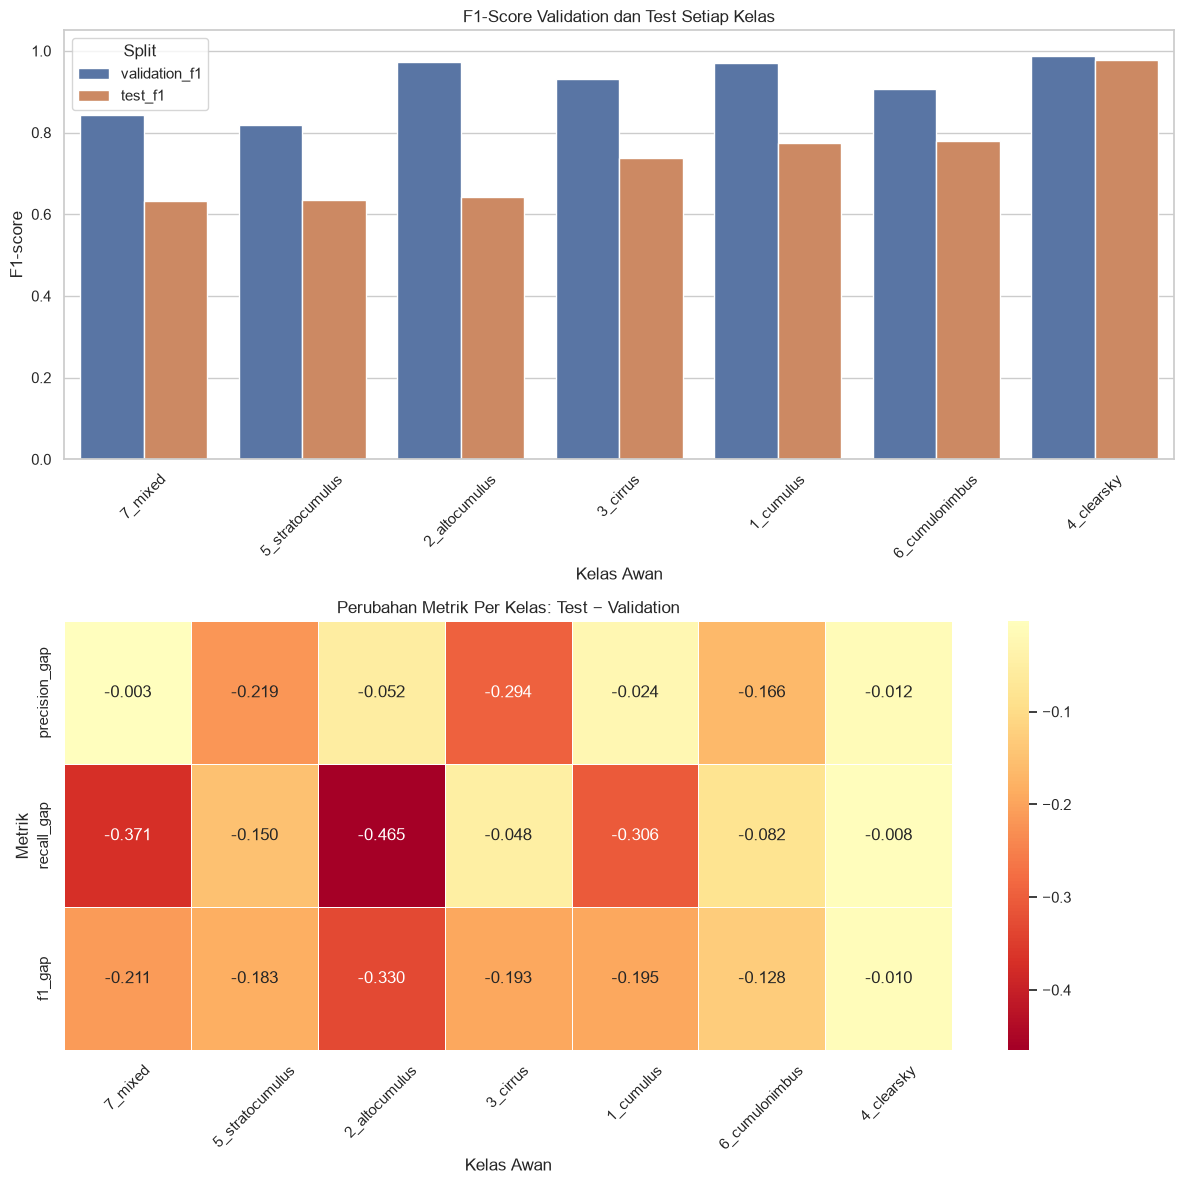

In [27]:
per_class_f1_plot_df = (
    per_class_comparison_df[
        [
            "class_name",
            "validation_f1",
            "test_f1",
        ]
    ]
    .melt(
        id_vars="class_name",
        var_name="split",
        value_name="f1_score",
    )
)


gap_heatmap_df = (
    per_class_comparison_df
    .set_index("class_name")[
        [
            "precision_gap",
            "recall_gap",
            "f1_gap",
        ]
    ]
    .transpose()
)


figure, axes = plt.subplots(
    2,
    1,
    figsize=(
        max(
            12,
            NUM_CLASSES * 1.25,
        ),
        12,
    ),
)


sns.barplot(
    data=per_class_f1_plot_df,
    x="class_name",
    y="f1_score",
    hue="split",
    ax=axes[0],
)

axes[0].set_ylim(
    0.0,
    1.05,
)

axes[0].set_title(
    "F1-Score Validation dan Test Setiap Kelas"
)

axes[0].set_xlabel(
    "Kelas Awan"
)

axes[0].set_ylabel(
    "F1-score"
)

axes[0].tick_params(
    axis="x",
    rotation=45,
)

axes[0].legend(
    title="Split"
)


sns.heatmap(
    gap_heatmap_df,
    annot=True,
    fmt="+.3f",
    cmap="RdYlGn",
    center=0.0,
    linewidths=0.5,
    ax=axes[1],
)

axes[1].set_title(
    "Perubahan Metrik Per Kelas: Test − Validation"
)

axes[1].set_xlabel(
    "Kelas Awan"
)

axes[1].set_ylabel(
    "Metrik"
)

axes[1].tick_params(
    axis="x",
    rotation=45,
)


plt.tight_layout()

plt.savefig(
    PER_CLASS_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [28]:
weakest_test_class = (
    per_class_comparison_df
    .sort_values(
        [
            "test_f1",
            "test_recall",
        ],
        ascending=[
            True,
            True,
        ],
    )
    .iloc[0]
)


lowest_f1_change_class = (
    per_class_comparison_df
    .sort_values(
        [
            "f1_gap",
            "test_f1",
        ],
        ascending=[
            True,
            True,
        ],
    )
    .iloc[0]
)


highest_error_rate_class = (
    per_class_comparison_df
    .sort_values(
        "test_error_rate",
        ascending=False,
    )
    .iloc[0]
)


priority_class_df = pd.DataFrame({
    "Indikator": [
        "F1-score test terendah",
        "Perubahan F1 paling rendah",
        "Error rate test tertinggi",
    ],
    "Kelas": [
        weakest_test_class["class_name"],
        lowest_f1_change_class["class_name"],
        highest_error_rate_class["class_name"],
    ],
    "Nilai": [
        weakest_test_class["test_f1"],
        lowest_f1_change_class["f1_gap"],
        highest_error_rate_class["test_error_rate"],
    ],
})


display(
    priority_class_df.style.format({
        "Nilai": "{:.6f}",
    })
)

,Indikator,Kelas,Nilai
0,F1-score test terendah,7_mixed,0.633037
1,Perubahan F1 paling rendah,2_altocumulus,-0.330355
2,Error rate test tertinggi,2_altocumulus,0.513333


In [29]:
total_test_errors = int(
    (~test_predictions_df["correct"])
    .sum()
)


if test_error_pairs_df.empty:
    dominant_error_pairs_df = pd.DataFrame({
        "true_class": [],
        "predicted_class": [],
        "error_count": [],
        "mean_confidence": [],
        "mean_margin": [],
        "error_share": [],
        "cumulative_error_share": [],
    })

    print(
        "Tidak terdapat kesalahan klasifikasi pada test split."
    )

else:
    dominant_error_pairs_df = (
        test_error_pairs_df
        .copy()
    )

    dominant_error_pairs_df["error_share"] = (
        dominant_error_pairs_df["error_count"]
        / total_test_errors
    )

    dominant_error_pairs_df[
        "cumulative_error_share"
    ] = (
        dominant_error_pairs_df[
            "error_share"
        ]
        .cumsum()
    )

    dominant_error_pairs_df = (
        dominant_error_pairs_df
        .sort_values(
            [
                "error_count",
                "mean_confidence",
            ],
            ascending=[
                False,
                False,
            ],
        )
        .reset_index(drop=True)
    )


display(
    dominant_error_pairs_df
    .head(15)
    .style.format({
        "mean_confidence": "{:.4f}",
        "mean_margin": "{:.4f}",
        "error_share": "{:.2%}",
        "cumulative_error_share": "{:.2%}",
    })
)

,true_class,predicted_class,error_count,mean_confidence,mean_margin,error_share,cumulative_error_share
0,5_stratocumulus,6_cumulonimbus,564,0.5677,0.3715,26.53%,26.53%
1,6_cumulonimbus,5_stratocumulus,412,0.5799,0.3759,19.38%,45.91%
2,2_altocumulus,6_cumulonimbus,130,0.5552,0.3644,6.11%,52.02%
3,1_cumulus,3_cirrus,124,0.6937,0.5651,5.83%,57.86%
4,2_altocumulus,5_stratocumulus,121,0.5058,0.2884,5.69%,63.55%
5,2_altocumulus,3_cirrus,102,0.5691,0.3758,4.80%,68.34%
6,7_mixed,6_cumulonimbus,101,0.5446,0.3255,4.75%,73.10%
7,7_mixed,3_cirrus,93,0.6516,0.4907,4.37%,77.47%
8,1_cumulus,6_cumulonimbus,85,0.5188,0.3276,4.00%,81.47%
9,7_mixed,5_stratocumulus,64,0.5109,0.3027,3.01%,84.48%


In [30]:
confidence_bins = [
    0.0,
    0.50,
    0.70,
    0.80,
    0.90,
    1.0,
]

confidence_labels = [
    "0.00–0.50",
    "0.50–0.70",
    "0.70–0.80",
    "0.80–0.90",
    "0.90–1.00",
]


test_predictions_df[
    "confidence_group"
] = pd.cut(
    test_predictions_df["confidence"],
    bins=confidence_bins,
    labels=confidence_labels,
    include_lowest=True,
)


confidence_group_df = (
    test_predictions_df
    .groupby(
        "confidence_group",
        observed=False,
    )
    .agg(
        sample_count=(
            "correct",
            "size",
        ),
        correct_count=(
            "correct",
            "sum",
        ),
        error_count=(
            "correct",
            lambda values: int(
                (~values).sum()
            ),
        ),
        empirical_accuracy=(
            "correct",
            "mean",
        ),
        mean_confidence=(
            "confidence",
            "mean",
        ),
        mean_margin=(
            "confidence_margin",
            "mean",
        ),
    )
    .reset_index()
)


confidence_group_df[
    "confidence_accuracy_gap"
] = (
    confidence_group_df["mean_confidence"]
    - confidence_group_df["empirical_accuracy"]
)


display(
    confidence_group_df.style.format({
        "empirical_accuracy": "{:.4f}",
        "mean_confidence": "{:.4f}",
        "mean_margin": "{:.4f}",
        "confidence_accuracy_gap": "{:+.4f}",
    })
)

,confidence_group,sample_count,correct_count,error_count,empirical_accuracy,mean_confidence,mean_margin,confidence_accuracy_gap
0,0.00–0.50,1335,574,761,0.4300,0.4218,0.1307,-0.0082
1,0.50–0.70,2960,2041,919,0.6895,0.6153,0.4515,-0.0743
2,0.70–0.80,2389,2086,303,0.8732,0.7552,0.6607,-0.1179
3,0.80–0.90,1690,1563,127,0.9249,0.8364,0.7686,-0.0884
4,0.90–1.00,626,610,16,0.9744,0.9408,0.9127,-0.0336


Expected Calibration Error (ECE) mengevaluasi kesesuaian antara confidence
prediksi dan tingkat kebenaran aktual.

ECE tidak mengukur kemampuan klasifikasi. Model dapat memiliki accuracy tinggi
tetapi confidence yang kurang terkalibrasi. Oleh karena itu, ECE harus
diinterpretasikan bersama accuracy, macro F1-score, dan confusion matrix.

In [31]:
CALIBRATION_BINS = 10


test_confidence = (
    test_predictions_df["confidence"]
    .to_numpy(
        dtype=np.float64
    )
)

test_correct = (
    test_predictions_df["correct"]
    .to_numpy(
        dtype=bool
    )
)


if (
    not np.isfinite(test_confidence).all()
    or np.any(test_confidence < 0.0)
    or np.any(test_confidence > 1.0)
):
    raise ValueError(
        "Nilai confidence test harus finite "
        "dan berada pada rentang 0 sampai 1."
    )


calibration_edges = np.linspace(
    0.0,
    1.0,
    CALIBRATION_BINS + 1,
)

calibration_bin_ids = np.digitize(
    test_confidence,
    calibration_edges[1:-1],
    right=False,
)


reliability_records = []
expected_calibration_error = 0.0


for bin_id in range(
    CALIBRATION_BINS
):
    current_mask = (
        calibration_bin_ids
        == bin_id
    )

    sample_count = int(
        current_mask.sum()
    )

    lower_bound = float(
        calibration_edges[bin_id]
    )

    upper_bound = float(
        calibration_edges[bin_id + 1]
    )


    if sample_count == 0:
        mean_confidence = np.nan
        bin_accuracy = np.nan
        calibration_gap = np.nan

    else:
        mean_confidence = float(
            test_confidence[
                current_mask
            ].mean()
        )

        bin_accuracy = float(
            test_correct[
                current_mask
            ].mean()
        )

        calibration_gap = abs(
            mean_confidence
            - bin_accuracy
        )

        expected_calibration_error += (
            sample_count
            / len(test_confidence)
        ) * calibration_gap


    reliability_records.append({
        "bin_id": bin_id + 1,
        "confidence_lower": lower_bound,
        "confidence_upper": upper_bound,
        "sample_count": sample_count,
        "mean_confidence": mean_confidence,
        "empirical_accuracy": bin_accuracy,
        "absolute_calibration_gap": calibration_gap,
    })


test_reliability_df = pd.DataFrame(
    reliability_records
)


maximum_calibration_error = float(
    test_reliability_df[
        "absolute_calibration_gap"
    ]
    .max(
        skipna=True
    )
)

top_label_brier_score = float(
    np.mean(
        (
            test_confidence
            - test_correct.astype(float)
        ) ** 2
    )
)


display(
    test_reliability_df.style.format({
        "confidence_lower": "{:.2f}",
        "confidence_upper": "{:.2f}",
        "mean_confidence": "{:.4f}",
        "empirical_accuracy": "{:.4f}",
        "absolute_calibration_gap": "{:.4f}",
    })
)


print(
    "Expected Calibration Error : "
    f"{expected_calibration_error:.6f}"
)

print(
    "Maximum Calibration Error  : "
    f"{maximum_calibration_error:.6f}"
)

print(
    "Top-label Brier score       : "
    f"{top_label_brier_score:.6f}"
)

,bin_id,confidence_lower,confidence_upper,sample_count,mean_confidence,empirical_accuracy,absolute_calibration_gap
0,1,0.00,0.10,0,nan,nan,nan
1,2,0.10,0.20,0,nan,nan,nan
2,3,0.20,0.30,46,0.2774,0.3043,0.0270
3,4,0.30,0.40,370,0.3656,0.3514,0.0142
4,5,0.40,0.50,919,0.4517,0.4679,0.0162
5,6,0.50,0.60,1129,0.5520,0.5748,0.0228
6,7,0.60,0.70,1831,0.6543,0.7602,0.1060
7,8,0.70,0.80,2389,0.7552,0.8732,0.1179
8,9,0.80,0.90,1690,0.8364,0.9249,0.0884
9,10,0.90,1.00,626,0.9408,0.9744,0.0336


Expected Calibration Error : 0.077051
Maximum Calibration Error  : 0.117938
Top-label Brier score       : 0.154543


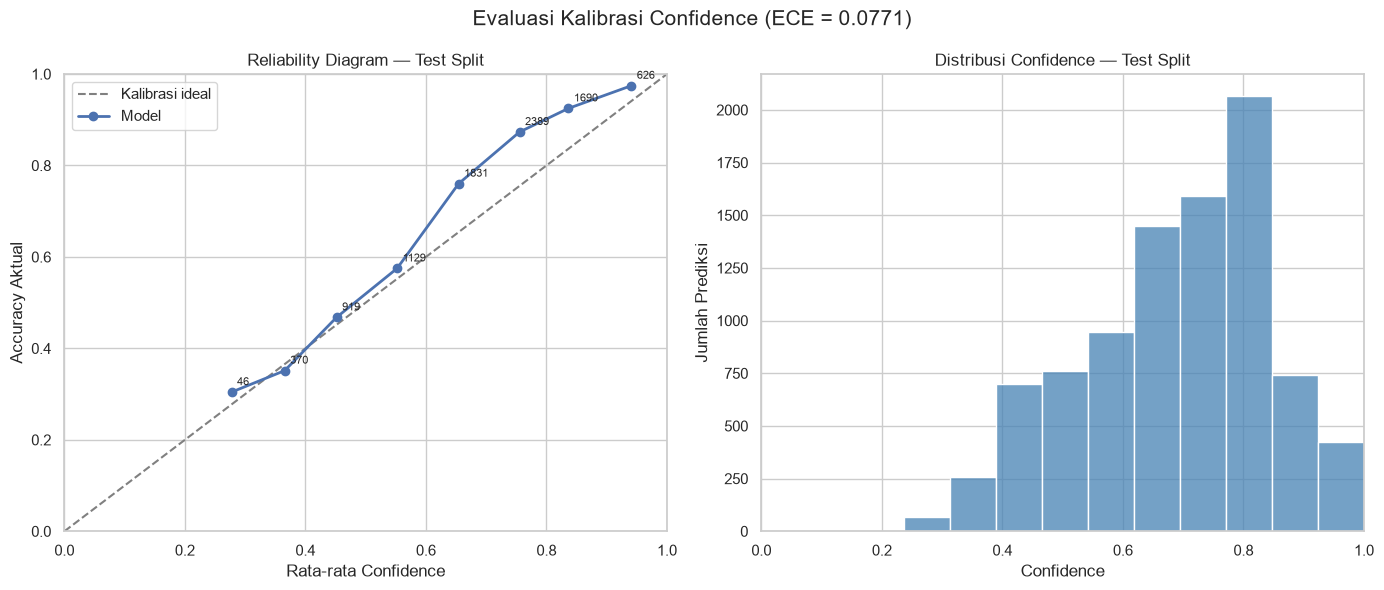

In [32]:
valid_reliability_df = (
    test_reliability_df
    .dropna(
        subset=[
            "mean_confidence",
            "empirical_accuracy",
        ]
    )
)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
)


axes[0].plot(
    [0.0, 1.0],
    [0.0, 1.0],
    linestyle="--",
    color="gray",
    label="Kalibrasi ideal",
)

axes[0].plot(
    valid_reliability_df[
        "mean_confidence"
    ],
    valid_reliability_df[
        "empirical_accuracy"
    ],
    marker="o",
    linewidth=2,
    label="Model",
)


for _, row in valid_reliability_df.iterrows():
    axes[0].annotate(
        str(
            int(row["sample_count"])
        ),
        (
            row["mean_confidence"],
            row["empirical_accuracy"],
        ),
        xytext=(4, 5),
        textcoords="offset points",
        fontsize=8,
    )


axes[0].set_title(
    "Reliability Diagram — Test Split"
)

axes[0].set_xlabel(
    "Rata-rata Confidence"
)

axes[0].set_ylabel(
    "Accuracy Aktual"
)

axes[0].set_xlim(
    0.0,
    1.0,
)

axes[0].set_ylim(
    0.0,
    1.0,
)

axes[0].legend()


sns.histplot(
    test_predictions_df,
    x="confidence",
    bins=10,
    ax=axes[1],
    color="steelblue",
)

axes[1].set_title(
    "Distribusi Confidence — Test Split"
)

axes[1].set_xlabel(
    "Confidence"
)

axes[1].set_ylabel(
    "Jumlah Prediksi"
)

axes[1].set_xlim(
    0.0,
    1.0,
)


figure.suptitle(
    (
        "Evaluasi Kalibrasi Confidence "
        f"(ECE = {expected_calibration_error:.4f})"
    ),
    fontsize=15,
)

plt.tight_layout()

plt.savefig(
    RELIABILITY_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

Kelayakan model tidak boleh ditentukan menggunakan ambang yang dibuat setelah
melihat hasil test. Jika penelitian memiliki kebutuhan operasional tertentu,
ambang penerimaan harus ditetapkan berdasarkan tujuan sistem, risiko kesalahan,
dan kebutuhan pengguna.

Isi nilai berikut hanya jika kriteria telah ditetapkan sebelumnya. Biarkan
`None` apabila belum tersedia.

In [33]:
ACCEPTANCE_CRITERIA = {
    "minimum_test_accuracy": None,
    "minimum_test_macro_f1": None,
    "minimum_lowest_class_recall": None,
    "maximum_absolute_macro_f1_gap": None,
    "maximum_test_ece": None,
}

In [34]:
test_accuracy_value = float(
    test_metrics["accuracy"]
)

test_macro_f1_value = float(
    test_metrics["f1_macro"]
)

lowest_test_recall_value = float(
    per_class_comparison_df[
        "test_recall"
    ].min()
)

macro_f1_gap_value = float(
    overall_comparison_df
    .loc[
        overall_comparison_df["metric"]
        == "F1-score macro",
        "test_minus_validation",
    ]
    .iloc[0]
)


criterion_specifications = [
    {
        "criterion": "Minimum test accuracy",
        "observed": test_accuracy_value,
        "threshold": ACCEPTANCE_CRITERIA[
            "minimum_test_accuracy"
        ],
        "operator": ">=",
    },
    {
        "criterion": "Minimum test macro F1",
        "observed": test_macro_f1_value,
        "threshold": ACCEPTANCE_CRITERIA[
            "minimum_test_macro_f1"
        ],
        "operator": ">=",
    },
    {
        "criterion": "Minimum recall kelas terendah",
        "observed": lowest_test_recall_value,
        "threshold": ACCEPTANCE_CRITERIA[
            "minimum_lowest_class_recall"
        ],
        "operator": ">=",
    },
    {
        "criterion": "Maksimum absolute macro F1 gap",
        "observed": abs(
            macro_f1_gap_value
        ),
        "threshold": ACCEPTANCE_CRITERIA[
            "maximum_absolute_macro_f1_gap"
        ],
        "operator": "<=",
    },
    {
        "criterion": "Maksimum test ECE",
        "observed": float(
            expected_calibration_error
        ),
        "threshold": ACCEPTANCE_CRITERIA[
            "maximum_test_ece"
        ],
        "operator": "<=",
    },
]

In [35]:
acceptance_records = []


for specification in criterion_specifications:
    threshold = specification[
        "threshold"
    ]

    if threshold is None:
        passed = None
        status = "Tidak ditetapkan"

    elif specification["operator"] == ">=":
        passed = (
            specification["observed"]
            >= float(threshold)
        )

        status = (
            "Memenuhi"
            if passed
            else "Belum memenuhi"
        )

    else:
        passed = (
            specification["observed"]
            <= float(threshold)
        )

        status = (
            "Memenuhi"
            if passed
            else "Belum memenuhi"
        )


    acceptance_records.append({
        "criterion": specification["criterion"],
        "observed": specification["observed"],
        "operator": specification["operator"],
        "threshold": threshold,
        "passed": passed,
        "status": status,
    })


acceptance_df = pd.DataFrame(
    acceptance_records
)


evaluated_criteria = (
    acceptance_df["passed"]
    .dropna()
)


if evaluated_criteria.empty:
    acceptance_status = (
        "Belum dinilai karena kriteria penerimaan "
        "belum ditetapkan."
    )

elif evaluated_criteria.astype(bool).all():
    acceptance_status = (
        "Memenuhi seluruh kriteria penerimaan "
        "yang telah ditetapkan."
    )

else:
    acceptance_status = (
        "Belum memenuhi seluruh kriteria penerimaan "
        "yang telah ditetapkan."
    )


display(
    acceptance_df.style.format({
        "observed": "{:.6f}",
        "threshold": (
            lambda value: (
                "-"
                if pd.isna(value)
                else f"{value:.6f}"
            )
        ),
    })
)

print(acceptance_status)

,criterion,observed,operator,threshold,passed,status
0,Minimum test accuracy,0.763778,>=,-,None,Tidak ditetapkan
1,Minimum test macro F1,0.739866,>=,-,None,Tidak ditetapkan
2,Minimum recall kelas terendah,0.486667,>=,-,None,Tidak ditetapkan
3,Maksimum absolute macro F1 gap,0.178572,<=,-,None,Tidak ditetapkan
4,Maksimum test ECE,0.077051,<=,-,None,Tidak ditetapkan


Belum dinilai karena kriteria penerimaan belum ditetapkan.


In [36]:
accuracy_gap_value = float(
    overall_comparison_df
    .loc[
        overall_comparison_df["metric"]
        == "Accuracy",
        "test_minus_validation",
    ]
    .iloc[0]
)


macro_f1_bootstrap_row = (
    bootstrap_ci_df
    .loc[
        bootstrap_ci_df["metric"]
        == "Macro F1-score"
    ]
    .iloc[0]
)


if dominant_error_pairs_df.empty:
    dominant_error_description = (
        "Tidak terdapat kesalahan prediksi."
    )

    dominant_error_record = None

else:
    dominant_error_row = (
        dominant_error_pairs_df
        .iloc[0]
    )

    dominant_error_description = (
        f"{dominant_error_row['true_class']} → "
        f"{dominant_error_row['predicted_class']} "
        f"sebanyak {int(dominant_error_row['error_count'])} kesalahan"
    )

    dominant_error_record = {
        "true_class": str(
            dominant_error_row["true_class"]
        ),
        "predicted_class": str(
            dominant_error_row["predicted_class"]
        ),
        "error_count": int(
            dominant_error_row["error_count"]
        ),
        "error_share": float(
            dominant_error_row["error_share"]
        ),
    }


key_findings_df = pd.DataFrame({
    "Indikator": [
        "Accuracy test",
        "Accuracy gap test − validation",
        "Macro F1 test",
        "Macro F1 gap test − validation",
        "Macro F1 CI 95% bawah",
        "Macro F1 CI 95% atas",
        "Kelas F1 test terendah",
        "F1 kelas terendah",
        "Kelas recall test terendah",
        "Recall terendah",
        "Expected Calibration Error",
        "Kesalahan dominan",
        "Status kriteria penerimaan",
    ],
    "Nilai": [
        test_accuracy_value,
        accuracy_gap_value,
        test_macro_f1_value,
        macro_f1_gap_value,
        macro_f1_bootstrap_row["ci_95_lower"],
        macro_f1_bootstrap_row["ci_95_upper"],
        weakest_test_class["class_name"],
        weakest_test_class["test_f1"],
        highest_error_rate_class["class_name"],
        per_class_comparison_df["test_recall"].min(),
        expected_calibration_error,
        dominant_error_description,
        acceptance_status,
    ],
})


display(key_findings_df)

,Indikator,Nilai
0,Accuracy test,0.763778
1,Accuracy gap test − validation,-0.153439
2,Macro F1 test,0.739866
3,Macro F1 gap test − validation,-0.178572
4,Macro F1 CI 95% bawah,0.729448
5,Macro F1 CI 95% atas,0.749886
6,Kelas F1 test terendah,7_mixed
7,F1 kelas terendah,0.633037
8,Kelas recall test terendah,2_altocumulus
9,Recall terendah,0.486667


In [37]:
overall_comparison_df.to_csv(
    OVERALL_COMPARISON_PATH,
    index=False,
    encoding="utf-8",
)

bootstrap_ci_df.to_csv(
    BOOTSTRAP_CI_PATH,
    index=False,
    encoding="utf-8",
)

per_class_comparison_df.to_csv(
    PER_CLASS_COMPARISON_PATH,
    index=False,
    encoding="utf-8",
)

dominant_error_pairs_df.to_csv(
    ERROR_ANALYSIS_PATH,
    index=False,
    encoding="utf-8",
)

confidence_group_df.to_csv(
    CONFIDENCE_GROUP_PATH,
    index=False,
    encoding="utf-8",
)

test_reliability_df.to_csv(
    RELIABILITY_PATH,
    index=False,
    encoding="utf-8",
)

acceptance_df.to_csv(
    ACCEPTANCE_PATH,
    index=False,
    encoding="utf-8",
)


print("Tabel evaluasi berhasil disimpan:")
print(f"- {OVERALL_COMPARISON_PATH.relative_to(PROJECT_DIR)}")
print(f"- {BOOTSTRAP_CI_PATH.relative_to(PROJECT_DIR)}")
print(f"- {PER_CLASS_COMPARISON_PATH.relative_to(PROJECT_DIR)}")
print(f"- {ERROR_ANALYSIS_PATH.relative_to(PROJECT_DIR)}")
print(f"- {CONFIDENCE_GROUP_PATH.relative_to(PROJECT_DIR)}")
print(f"- {RELIABILITY_PATH.relative_to(PROJECT_DIR)}")
print(f"- {ACCEPTANCE_PATH.relative_to(PROJECT_DIR)}")

Tabel evaluasi berhasil disimpan:
- logs\resnet18_evaluation_20260826_141227_532648\overall_metric_comparison.csv
- logs\resnet18_evaluation_20260826_141227_532648\test_bootstrap_confidence_intervals.csv
- logs\resnet18_evaluation_20260826_141227_532648\per_class_generalization.csv
- logs\resnet18_evaluation_20260826_141227_532648\dominant_error_pairs.csv
- logs\resnet18_evaluation_20260826_141227_532648\test_confidence_groups.csv
- logs\resnet18_evaluation_20260826_141227_532648\test_reliability.csv
- logs\resnet18_evaluation_20260826_141227_532648\acceptance_criteria.csv


In [38]:
def json_safe(
    value,
):
    """
    Mengubah objek NumPy, Pandas, dan nilai non-finite
    menjadi format yang kompatibel dengan JSON.
    """
    if isinstance(
        value,
        np.generic,
    ):
        value = value.item()

    if isinstance(
        value,
        Path,
    ):
        return str(value)

    if isinstance(
        value,
        dict,
    ):
        return {
            str(key): json_safe(item)
            for key, item
            in value.items()
        }

    if isinstance(
        value,
        (list, tuple),
    ):
        return [
            json_safe(item)
            for item in value
        ]

    if isinstance(
        value,
        float,
    ) and not np.isfinite(value):
        return None

    return value

In [39]:
evaluation_summary = {
    "created_at": (
        datetime.now()
        .astimezone()
        .isoformat(timespec="seconds")
    ),

    "stage": "11_evaluasi_model",
    "evaluation_run_id": EVALUATION_RUN_ID,

    "evaluation_design": {
        "source": "saved_artifacts",
        "model_inference_performed": False,
        "model_weights_loaded": False,
        "model_weights_updated": False,
        "test_used_for_model_selection": False,
        "test_used_for_hyperparameter_tuning": False,
    },

    "model": {
        "model_name": MODEL_NAME,
        "num_classes": NUM_CLASSES,
        "class_to_idx": CLASS_TO_IDX,
        "input_shape": model_config["input_shape"],
    },

    "checkpoint": {
        "path": str(
            CHECKPOINT_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "sha256": CHECKPOINT_SHA256_ACTUAL,
        "validation_and_test_checkpoint_match": True,
    },

    "selected_runs": {
        "validation": str(
            VALIDATION_RUN_DIR.relative_to(
                PROJECT_DIR
            )
        ),
        "test": str(
            TEST_RUN_DIR.relative_to(
                PROJECT_DIR
            )
        ),
    },

    "sample_counts": {
        "validation": int(
            len(validation_predictions_df)
        ),
        "test": int(
            len(test_predictions_df)
        ),
    },

    "test_metrics": {
        "accuracy": test_accuracy_value,
        "balanced_accuracy": float(
            test_metrics["balanced_accuracy"]
        ),
        "precision_macro": float(
            test_metrics["precision_macro"]
        ),
        "recall_macro": float(
            test_metrics["recall_macro"]
        ),
        "f1_macro": test_macro_f1_value,
        "f1_weighted": float(
            test_metrics["f1_weighted"]
        ),
        "log_loss": float(
            test_metrics["log_loss"]
        ),
    },

    "generalization": {
        row["metric"]: {
            "validation": float(
                row["validation"]
            ),
            "test": float(
                row["test"]
            ),
            "test_minus_validation": float(
                row["test_minus_validation"]
            ),
        }
        for _, row
        in overall_comparison_df.iterrows()
    },

    "bootstrap_confidence_intervals": (
        bootstrap_ci_df
        .to_dict(
            orient="records"
        )
    ),

    "calibration": {
        "number_of_bins": CALIBRATION_BINS,
        "expected_calibration_error": float(
            expected_calibration_error
        ),
        "maximum_calibration_error": float(
            maximum_calibration_error
        ),
        "top_label_brier_score": float(
            top_label_brier_score
        ),
    },

    "class_findings": {
        "lowest_test_f1": {
            "class_name": str(
                weakest_test_class[
                    "class_name"
                ]
            ),
            "f1_score": float(
                weakest_test_class[
                    "test_f1"
                ]
            ),
            "recall": float(
                weakest_test_class[
                    "test_recall"
                ]
            ),
        },

        "lowest_f1_change": {
            "class_name": str(
                lowest_f1_change_class[
                    "class_name"
                ]
            ),
            "f1_gap": float(
                lowest_f1_change_class[
                    "f1_gap"
                ]
            ),
        },

        "highest_test_error_rate": {
            "class_name": str(
                highest_error_rate_class[
                    "class_name"
                ]
            ),
            "error_rate": float(
                highest_error_rate_class[
                    "test_error_rate"
                ]
            ),
        },
    },

    "error_analysis": {
        "number_of_test_errors": (
            total_test_errors
        ),
        "dominant_error_pair": (
            dominant_error_record
        ),
    },

    "acceptance_evaluation": {
        "status": acceptance_status,
        "criteria": (
            acceptance_df
            .to_dict(
                orient="records"
            )
        ),
    },

    "input_artifact_sha256": (
        SOURCE_HASHES_BEFORE
    ),

    "output_artifacts": {
        "overall_comparison": str(
            OVERALL_COMPARISON_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "bootstrap_confidence_intervals": str(
            BOOTSTRAP_CI_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "per_class_generalization": str(
            PER_CLASS_COMPARISON_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "dominant_error_pairs": str(
            ERROR_ANALYSIS_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "test_reliability": str(
            RELIABILITY_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "evaluation_report": str(
            EVALUATION_REPORT_PATH.relative_to(
                PROJECT_DIR
            )
        ),
    },
}


evaluation_summary = json_safe(
    evaluation_summary
)


with EVALUATION_SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        evaluation_summary,
        file,
        indent=2,
        ensure_ascii=False,
        allow_nan=False,
    )


print(
    "Ringkasan JSON disimpan:\n"
    f"{EVALUATION_SUMMARY_PATH.relative_to(PROJECT_DIR)}"
)

Ringkasan JSON disimpan:
logs\resnet18_evaluation_20260826_141227_532648\model_evaluation_summary.json


In [40]:
accuracy_ci_row = (
    bootstrap_ci_df
    .loc[
        bootstrap_ci_df["metric"]
        == "Accuracy"
    ]
    .iloc[0]
)


evaluation_report = f"""# Laporan Evaluasi Akhir Model

## Identitas Model

- Model: `{MODEL_NAME}`
- Jumlah kelas: {NUM_CLASSES}
- Checkpoint: `{CHECKPOINT_PATH.relative_to(PROJECT_DIR)}`
- SHA-256 checkpoint: `{CHECKPOINT_SHA256_ACTUAL}`
- Jumlah data validation: {len(validation_predictions_df):,}
- Jumlah data test: {len(test_predictions_df):,}

## Performa Test

- Accuracy: {test_accuracy_value:.4%}
- Accuracy CI 95%: {accuracy_ci_row["ci_95_lower"]:.4%}–{accuracy_ci_row["ci_95_upper"]:.4%}
- Balanced accuracy: {float(test_metrics["balanced_accuracy"]):.4%}
- Macro F1-score: {test_macro_f1_value:.4%}
- Macro F1 CI 95%: {macro_f1_bootstrap_row["ci_95_lower"]:.4%}–{macro_f1_bootstrap_row["ci_95_upper"]:.4%}
- Weighted F1-score: {float(test_metrics["f1_weighted"]):.4%}
- Log loss: {float(test_metrics["log_loss"]):.6f}

## Generalisasi

- Accuracy validation: {float(validation_metrics["accuracy"]):.4%}
- Accuracy test: {test_accuracy_value:.4%}
- Selisih accuracy test − validation: {accuracy_gap_value:+.4%}
- Macro F1 validation: {float(validation_metrics["f1_macro"]):.4%}
- Macro F1 test: {test_macro_f1_value:.4%}
- Selisih macro F1 test − validation: {macro_f1_gap_value:+.4%}

## Performa Kelas

- Kelas dengan F1 test terendah: `{weakest_test_class["class_name"]}`
- F1-score kelas tersebut: {float(weakest_test_class["test_f1"]):.4%}
- Recall kelas tersebut: {float(weakest_test_class["test_recall"]):.4%}
- Kelas dengan error rate tertinggi: `{highest_error_rate_class["class_name"]}`
- Error rate kelas tersebut: {float(highest_error_rate_class["test_error_rate"]):.4%}

## Kalibrasi Confidence

- Expected Calibration Error: {expected_calibration_error:.6f}
- Maximum Calibration Error: {maximum_calibration_error:.6f}
- Top-label Brier score: {top_label_brier_score:.6f}

## Pola Kesalahan

- Jumlah kesalahan test: {total_test_errors:,}
- Pasangan kesalahan dominan: {dominant_error_description}

## Kriteria Penerimaan

{acceptance_status}

## Catatan Metodologis

Evaluasi ini menggunakan prediksi yang telah disimpan oleh notebook validation
dan pengujian. Model tidak dimuat, inference tidak diulang, dan bobot model tidak
diperbarui. Data test tidak digunakan untuk pemilihan model maupun penyesuaian
hyperparameter.
"""


EVALUATION_REPORT_PATH.write_text(
    evaluation_report,
    encoding="utf-8",
)


print(evaluation_report)

# Laporan Evaluasi Akhir Model

## Identitas Model

- Model: `resnet18`
- Jumlah kelas: 7
- Checkpoint: `models\resnet18_gcd_best.pth`
- SHA-256 checkpoint: `e9f134760047e2075fe154a0e99c32786e456e6e37790ea1e46e1717af6eb0aa`
- Jumlah data validation: 1,969
- Jumlah data test: 9,000

## Performa Test

- Accuracy: 76.3778%
- Accuracy CI 95%: 75.5333%–77.1889%
- Balanced accuracy: 71.6141%
- Macro F1-score: 73.9866%
- Macro F1 CI 95%: 72.9448%–74.9886%
- Weighted F1-score: 76.0221%
- Log loss: 0.759603

## Generalisasi

- Accuracy validation: 91.7217%
- Accuracy test: 76.3778%
- Selisih accuracy test − validation: -15.3439%
- Macro F1 validation: 91.8438%
- Macro F1 test: 73.9866%
- Selisih macro F1 test − validation: -17.8572%

## Performa Kelas

- Kelas dengan F1 test terendah: `7_mixed`
- F1-score kelas tersebut: 63.3037%
- Recall kelas tersebut: 52.7183%
- Kelas dengan error rate tertinggi: `2_altocumulus`
- Error rate kelas tersebut: 51.3333%

## Kalibrasi Confidence

- Expected Calib

In [41]:
SOURCE_HASHES_AFTER = {
    artifact_name: calculate_sha256(path)
    for artifact_name, path
    in SOURCE_ARTIFACTS.items()
}


source_integrity_df = pd.DataFrame({
    "Artefak": SOURCE_HASHES_BEFORE.keys(),
    "Hash sebelum": SOURCE_HASHES_BEFORE.values(),
    "Hash setelah": SOURCE_HASHES_AFTER.values(),
})


source_integrity_df["Tidak berubah"] = (
    source_integrity_df["Hash sebelum"]
    == source_integrity_df["Hash setelah"]
)


display(source_integrity_df)


if not source_integrity_df[
    "Tidak berubah"
].all():
    changed_artifacts = (
        source_integrity_df
        .loc[
            ~source_integrity_df[
                "Tidak berubah"
            ],
            "Artefak",
        ]
        .tolist()
    )

    raise RuntimeError(
        "Artefak sumber berubah selama evaluasi: "
        f"{changed_artifacts}"
    )


print("Seluruh artefak sumber tetap tidak berubah.")

,Artefak,Hash sebelum,Hash setelah,Tidak berubah
0,model_config,d9ee02e3a15742953868fb2f660bb08c442b56bc27455eade730192849893e37,d9ee02e3a15742953868fb2f660bb08c442b56bc27455eade730192849893e37,True
1,validation_summary,f5a9d1d2ee54caad3778f28c88ed3cd163e90acf0e01f978ddbf5ac4aefbf6a7,f5a9d1d2ee54caad3778f28c88ed3cd163e90acf0e01f978ddbf5ac4aefbf6a7,True
2,validation_predictions,c1c348021ba7e43bd3de1c269a1724d41558a671ddc869bce4c48d86a1293b5e,c1c348021ba7e43bd3de1c269a1724d41558a671ddc869bce4c48d86a1293b5e,True
3,validation_per_class,a62ee1da94d2c682f3323119719d1ff20be00e235aa360cf1f4bed8eecc60955,a62ee1da94d2c682f3323119719d1ff20be00e235aa360cf1f4bed8eecc60955,True
4,test_summary,56078c7a7dfb21f3aa6a09bfdc17db2513965ae1c465b6d23afa4e5b138bddc3,56078c7a7dfb21f3aa6a09bfdc17db2513965ae1c465b6d23afa4e5b138bddc3,True
5,test_predictions,693d2478634a528a77a46705c0e8aa7c7132e7d0786386ebe3e72d68537f8881,693d2478634a528a77a46705c0e8aa7c7132e7d0786386ebe3e72d68537f8881,True
6,test_per_class,495487afafa1cf3a69d62c21437779ba4a1a3e6efe29b85574e837248e726f8d,495487afafa1cf3a69d62c21437779ba4a1a3e6efe29b85574e837248e726f8d,True
7,test_error_pairs,9e1a1ee055abf366912f1a0e6e016c7ed22a53d0a06348cb16c0e532f1a9bcb1,9e1a1ee055abf366912f1a0e6e016c7ed22a53d0a06348cb16c0e532f1a9bcb1,True
8,checkpoint,e9f134760047e2075fe154a0e99c32786e456e6e37790ea1e46e1717af6eb0aa,e9f134760047e2075fe154a0e99c32786e456e6e37790ea1e46e1717af6eb0aa,True


Seluruh artefak sumber tetap tidak berubah.


In [42]:
required_output_files = [
    OVERALL_COMPARISON_PATH,
    OVERALL_COMPARISON_FIGURE_PATH,
    BOOTSTRAP_CI_PATH,
    PER_CLASS_COMPARISON_PATH,
    PER_CLASS_FIGURE_PATH,
    ERROR_ANALYSIS_PATH,
    CONFIDENCE_GROUP_PATH,
    RELIABILITY_PATH,
    RELIABILITY_FIGURE_PATH,
    ACCEPTANCE_PATH,
    EVALUATION_SUMMARY_PATH,
    EVALUATION_REPORT_PATH,
]


final_checks = {
    "Audit provenance berhasil": (
        all(
            provenance_checks.values()
        )
    ),

    "Checkpoint validation dan test sama": (
        validation_checkpoint_sha
        == test_checkpoint_sha
    ),

    "Checkpoint aktual sesuai metadata": (
        CHECKPOINT_SHA256_ACTUAL
        == test_checkpoint_sha
    ),

    "Seluruh prediksi test dievaluasi": (
        len(y_test_true)
        == len(test_predictions_df)
    ),

    "Perbandingan metrik tersedia": (
        not overall_comparison_df.empty
    ),

    "Interval bootstrap tersedia": (
        len(bootstrap_ci_df) == 3
    ),

    "Metrik seluruh kelas tersedia": (
        len(per_class_comparison_df)
        == NUM_CLASSES
    ),

    "ECE berada pada rentang valid": (
        0.0
        <= expected_calibration_error
        <= 1.0
    ),

    "Artefak sumber tidak berubah": (
        source_integrity_df[
            "Tidak berubah"
        ].all()
    ),

    "Seluruh output tersimpan": all(
        path.is_file()
        for path in required_output_files
    ),

    "Inference model dijalankan": False,

    "Bobot model diperbarui": False,
}


final_check_df = pd.DataFrame({
    "Pemeriksaan": final_checks.keys(),
    "Nilai": final_checks.values(),
    "Status": [
        (
            "Sesuai"
            if (
                check_name
                in {
                    "Inference model dijalankan",
                    "Bobot model diperbarui",
                }
                and value is False
            )
            else (
                "Berhasil"
                if value
                else "Gagal"
            )
        )
        for check_name, value
        in final_checks.items()
    ],
})


display(final_check_df)


failed_final_checks = [
    check_name
    for check_name, status
    in final_checks.items()
    if (
        check_name
        not in {
            "Inference model dijalankan",
            "Bobot model diperbarui",
        }
        and not status
    )
]


if failed_final_checks:
    raise RuntimeError(
        "Pemeriksaan akhir evaluasi gagal:\n- "
        + "\n- ".join(failed_final_checks)
    )


print("Seluruh pemeriksaan akhir evaluasi berhasil.")

,Pemeriksaan,Nilai,Status
0,Audit provenance berhasil,True,Berhasil
1,Checkpoint validation dan test sama,True,Berhasil
2,Checkpoint aktual sesuai metadata,True,Berhasil
3,Seluruh prediksi test dievaluasi,True,Berhasil
4,Perbandingan metrik tersedia,True,Berhasil
5,Interval bootstrap tersedia,True,Berhasil
6,Metrik seluruh kelas tersedia,True,Berhasil
7,ECE berada pada rentang valid,True,Berhasil
8,Artefak sumber tidak berubah,True,Berhasil
9,Seluruh output tersimpan,True,Berhasil


Seluruh pemeriksaan akhir evaluasi berhasil.


In [43]:
print("=" * 78)
print("EVALUASI AKHIR MODEL SELESAI")
print("=" * 78)

print(
    f"Model                    : "
    f"{MODEL_NAME}"
)

print(
    f"Checkpoint               : "
    f"{CHECKPOINT_PATH.relative_to(PROJECT_DIR)}"
)

print(
    f"Jumlah data validation   : "
    f"{len(validation_predictions_df):,}"
)

print(
    f"Jumlah data test         : "
    f"{len(test_predictions_df):,}"
)

print(
    f"Accuracy test            : "
    f"{test_accuracy_value:.4%}"
)

print(
    f"Accuracy gap             : "
    f"{accuracy_gap_value:+.4%}"
)

print(
    f"Macro F1 test            : "
    f"{test_macro_f1_value:.4%}"
)

print(
    f"Macro F1 gap             : "
    f"{macro_f1_gap_value:+.4%}"
)

print(
    f"Macro F1 CI 95%          : "
    f"{macro_f1_bootstrap_row['ci_95_lower']:.4%} – "
    f"{macro_f1_bootstrap_row['ci_95_upper']:.4%}"
)

print(
    f"Kelas F1 terendah        : "
    f"{weakest_test_class['class_name']} "
    f"({weakest_test_class['test_f1']:.4f})"
)

print(
    f"Expected Calibration Err : "
    f"{expected_calibration_error:.6f}"
)

print(
    f"Jumlah kesalahan test    : "
    f"{total_test_errors:,}"
)

print(
    f"Kesalahan dominan        : "
    f"{dominant_error_description}"
)

print(
    f"Status penerimaan        : "
    f"{acceptance_status}"
)

print(
    f"Folder hasil             : "
    f"{EVALUATION_OUTPUT_DIR.relative_to(PROJECT_DIR)}"
)

print(
    "Inference diulang        : Tidak"
)

print(
    "Bobot model diperbarui   : Tidak"
)

print("=" * 78)

EVALUASI AKHIR MODEL SELESAI
Model                    : resnet18
Checkpoint               : models\resnet18_gcd_best.pth
Jumlah data validation   : 1,969
Jumlah data test         : 9,000
Accuracy test            : 76.3778%
Accuracy gap             : -15.3439%
Macro F1 test            : 73.9866%
Macro F1 gap             : -17.8572%
Macro F1 CI 95%          : 72.9448% – 74.9886%
Kelas F1 terendah        : 7_mixed (0.6330)
Expected Calibration Err : 0.077051
Jumlah kesalahan test    : 2,126
Kesalahan dominan        : 5_stratocumulus → 6_cumulonimbus sebanyak 564 kesalahan
Status penerimaan        : Belum dinilai karena kriteria penerimaan belum ditetapkan.
Folder hasil             : logs\resnet18_evaluation_20260826_141227_532648
Inference diulang        : Tidak
Bobot model diperbarui   : Tidak


In [44]:
output_artifact_df = pd.DataFrame({
    "Artefak": [
        "Perbandingan metrik",
        "Grafik perbandingan metrik",
        "Bootstrap confidence interval",
        "Generalisasi per kelas",
        "Grafik generalisasi per kelas",
        "Pasangan kesalahan dominan",
        "Kelompok confidence",
        "Reliability table",
        "Reliability diagram",
        "Kriteria penerimaan",
        "Ringkasan evaluasi JSON",
        "Laporan evaluasi Markdown",
    ],

    "Path": [
        OVERALL_COMPARISON_PATH,
        OVERALL_COMPARISON_FIGURE_PATH,
        BOOTSTRAP_CI_PATH,
        PER_CLASS_COMPARISON_PATH,
        PER_CLASS_FIGURE_PATH,
        ERROR_ANALYSIS_PATH,
        CONFIDENCE_GROUP_PATH,
        RELIABILITY_PATH,
        RELIABILITY_FIGURE_PATH,
        ACCEPTANCE_PATH,
        EVALUATION_SUMMARY_PATH,
        EVALUATION_REPORT_PATH,
    ],
})


output_artifact_df["Path"] = (
    output_artifact_df["Path"]
    .map(
        lambda path: str(
            path.relative_to(
                PROJECT_DIR
            )
        )
    )
)

output_artifact_df["Ada"] = [
    (
        PROJECT_DIR
        / relative_path
    ).is_file()
    for relative_path
    in output_artifact_df["Path"]
]


display(output_artifact_df)

,Artefak,Path,Ada
0,Perbandingan metrik,logs\resnet18_evaluation_20260826_141227_532648\overall_metric_comparison.csv,True
1,Grafik perbandingan metrik,logs\resnet18_evaluation_20260826_141227_532648\overall_metric_comparison.png,True
2,Bootstrap confidence interval,logs\resnet18_evaluation_20260826_141227_532648\test_bootstrap_confidence_intervals.csv,True
3,Generalisasi per kelas,logs\resnet18_evaluation_20260826_141227_532648\per_class_generalization.csv,True
4,Grafik generalisasi per kelas,logs\resnet18_evaluation_20260826_141227_532648\per_class_generalization.png,True
5,Pasangan kesalahan dominan,logs\resnet18_evaluation_20260826_141227_532648\dominant_error_pairs.csv,True
6,Kelompok confidence,logs\resnet18_evaluation_20260826_141227_532648\test_confidence_groups.csv,True
7,Reliability table,logs\resnet18_evaluation_20260826_141227_532648\test_reliability.csv,True
8,Reliability diagram,logs\resnet18_evaluation_20260826_141227_532648\test_reliability_diagram.png,True
9,Kriteria penerimaan,logs\resnet18_evaluation_20260826_141227_532648\acceptance_criteria.csv,True


## Interpretasi Hasil Evaluasi

Interpretasi dilakukan menggunakan beberapa sudut pandang.

### 1. Performa diskriminatif

Accuracy menunjukkan proporsi seluruh citra yang diklasifikasikan dengan benar.
Balanced accuracy dan macro F1-score memberikan perhatian yang sama terhadap
setiap kelas sehingga lebih informatif apabila distribusi kelas tidak seimbang.

### 2. Kemampuan generalisasi

Selisih antara validation dan test menunjukkan perubahan performa pada data
yang benar-benar tidak digunakan dalam pemilihan checkpoint. Selisih negatif
tidak secara otomatis membuktikan overfitting karena perbedaan juga dapat
dipengaruhi ukuran sampel, tingkat kesulitan citra, dan distribusi kelas.

### 3. Ketidakpastian hasil

Interval kepercayaan bootstrap menunjukkan rentang ketidakpastian estimasi
metrik. Interval yang lebar menunjukkan bahwa estimasi performa masih sensitif
terhadap komposisi sampel test.

### 4. Performa setiap kelas

Macro average yang baik belum menjamin seluruh jenis awan dikenali secara
konsisten. Kelas dengan recall rendah merupakan kelas yang banyak terlewat,
sedangkan precision rendah menunjukkan bahwa kelas tersebut sering diberikan
kepada citra dari kelas lain.

### 5. Kalibrasi confidence

Expected Calibration Error membandingkan confidence dengan accuracy aktual.
Nilai yang lebih kecil menunjukkan kesesuaian yang lebih baik, tetapi tidak ada
ambang universal yang otomatis menyatakan suatu model layak.

### 6. Kelayakan penggunaan

Keputusan kelayakan harus menggunakan kriteria yang ditetapkan berdasarkan
kebutuhan sistem sebelum hasil test digunakan. Jika kriteria penerimaan belum
ditetapkan, notebook hanya menyajikan bukti empiris tanpa memberikan keputusan
lulus atau gagal.

## Kesimpulan

Tahap evaluasi akhir telah dilaksanakan menggunakan artefak validation dan test
yang sudah tersimpan.

Pemeriksaan memastikan bahwa:

1. hasil validation dan test berasal dari model yang sama;
2. checkpoint validation dan test memiliki SHA-256 yang identik;
3. pemetaan kelas konsisten dengan `model_config.json`;
4. data test tidak digunakan untuk pemilihan model atau tuning hyperparameter;
5. inference test tidak dijalankan kembali;
6. bobot model tidak diperbarui;
7. metrik validation dan test telah dibandingkan;
8. interval kepercayaan test telah dihitung menggunakan stratified bootstrap;
9. performa setiap kelas dan pasangan kesalahan telah dianalisis;
10. kalibrasi confidence test telah dievaluasi;
11. seluruh hasil telah disimpan secara terstruktur.

Hasil dalam `model_evaluation_report.md` dan
`model_evaluation_summary.json` dapat digunakan sebagai dasar penyusunan bagian
hasil dan pembahasan penelitian.

Tahap berikutnya dapat diarahkan pada pembuatan pipeline prediksi satu citra,
penyusunan `src/evaluate.py`, atau implementasi model untuk inference.